# Battery Lifecycle RUL Prediction
Notebook ini menggunakan algoritma Machine Learning (XGBoost) untuk memprediksi sisa siklus pemakaian baterai (RUL) berdasarkan data sensor riil.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import os

# Ensure backend directory exists
os.makedirs('../backend', exist_ok=True)

## 1. Load Data Asli (Dari CSV)

In [27]:
# 1. Membaca Data Aki Asli
# Data ini diambil dari dataset_final_battery.csv yang telah diproses dari file Excel mentahan
df = pd.read_csv('../backend/dataset_final_battery.csv')
df.head()

,cycle,capacity,soh,voltage_drop,min_voltage,rul
0,1,4.5099,100.00,0.4889,12.9451,480
1,2,4.4972,99.72,0.5797,12.8956,479
2,3,4.5129,100.00,0.6103,12.8716,478
3,4,4.5304,100.00,0.6639,12.8945,477
4,5,4.4952,99.67,0.6833,12.8827,476


In [28]:
# 2. Data Cleaning & Feature Selection
df = df.dropna()

features = ['capacity', 'soh', 'voltage_drop', 'min_voltage']
target = 'rul'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (481, 4)
Target shape: (481,)


In [29]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (384, 4)
Testing data: (97, 4)


## 2. Train XGBoost Regressor Model

In [30]:
# 4. Train XGBoost Model
# XGBoost sangat bagus untuk memodelkan data non-linear seperti siklus baterai
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
print("Model training completed!")

Model training completed!


## 3. Evaluation

Mean Absolute Error (MAE): 4.80 cycles
Root Mean Squared Error (RMSE): 5.98 cycles
R-squared Score (R2): 0.9984


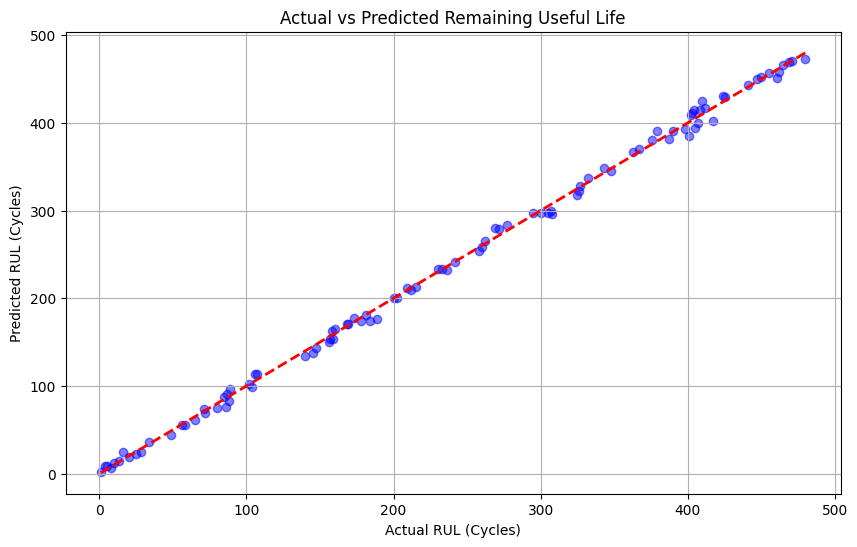

In [31]:
# 5. Model Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} cycles")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cycles")
print(f"R-squared Score (R2): {r2:.4f}")

# Plotting Predictions vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual RUL (Cycles)")
plt.ylabel("Predicted RUL (Cycles)")
plt.title("Actual vs Predicted Remaining Useful Life")
plt.grid(True)
plt.show()

## 4. Export Model for Web App

In [32]:
# 6. Save Model
# Simpan model untuk digunakan oleh Backend Flask (API)
model_path = '../backend/model_battery.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
    
print(f"Model successfully saved to {model_path}")

Model successfully saved to ../backend/model_battery.pkl


## 5. Visualisasi Outlier (Box Plot)

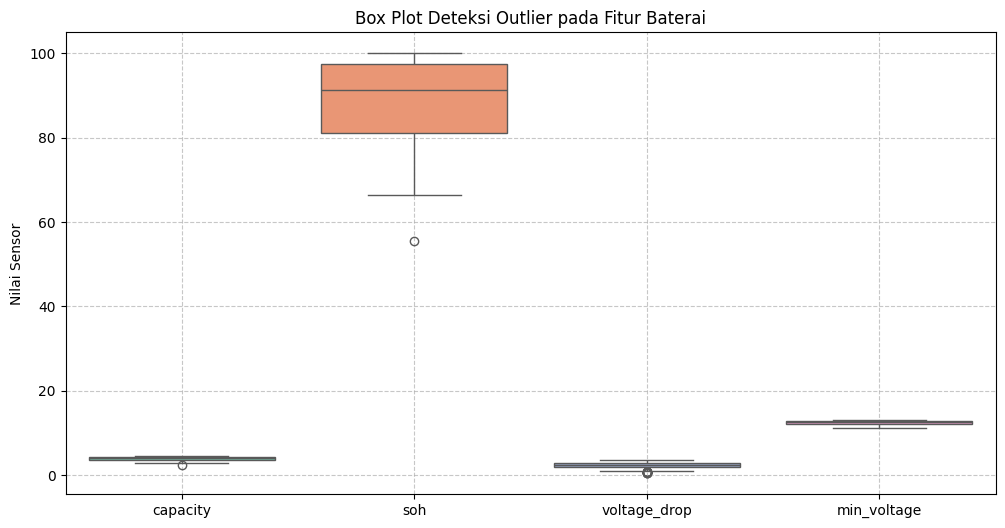

In [33]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features], palette='Set2')
plt.title('Box Plot Deteksi Outlier pada Fitur Baterai')
plt.ylabel('Nilai Sensor')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Distribusi Data (Histogram)

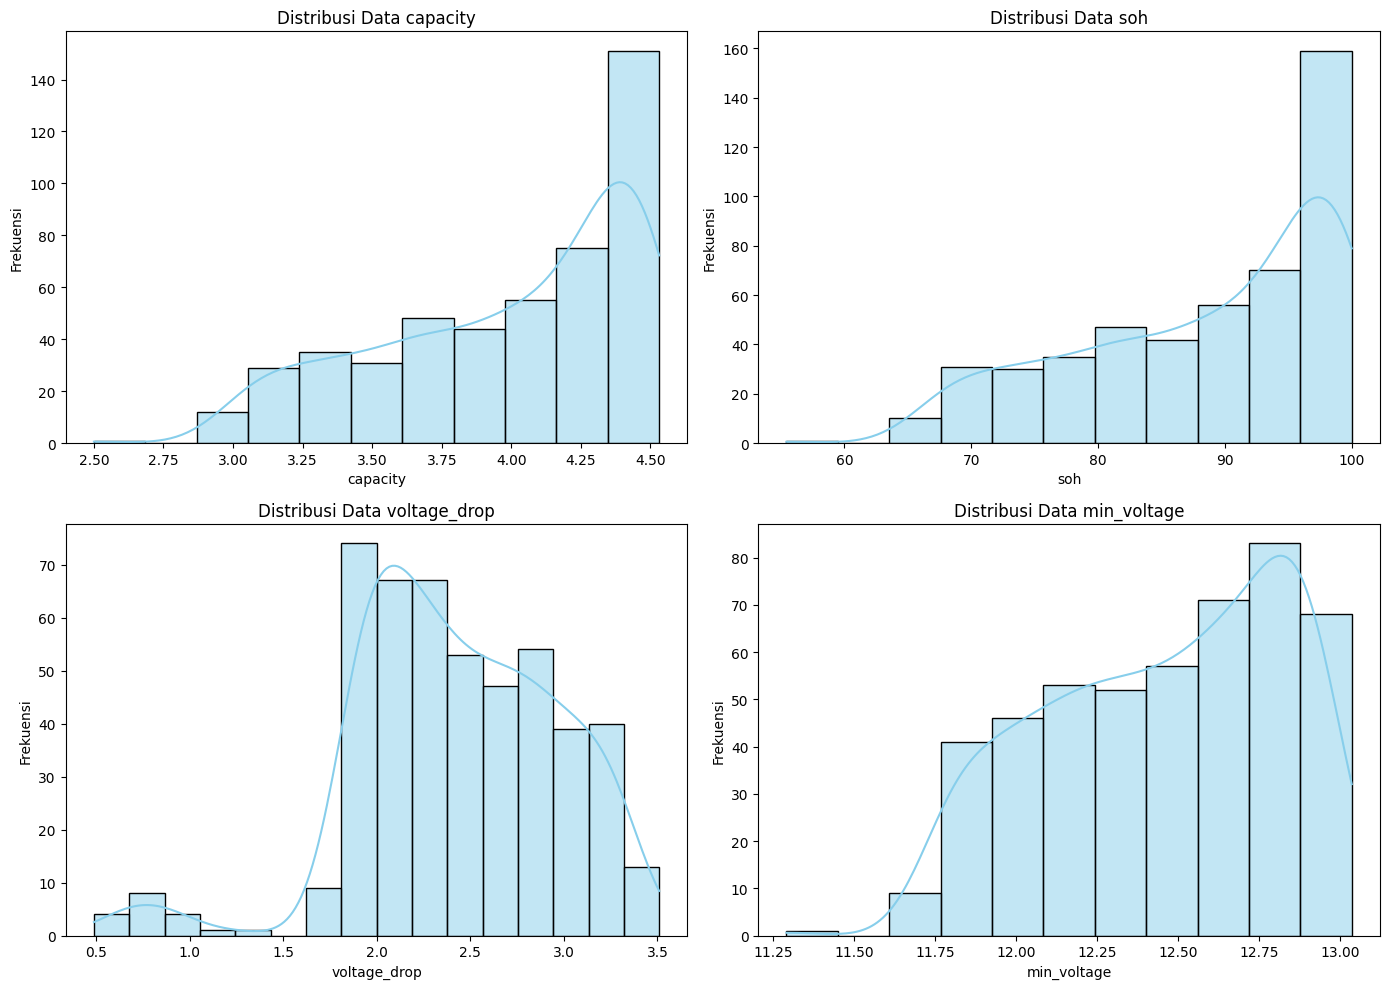

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi Data {col}')
    axes[i].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

## 7. Hasil Prediksi: Actual vs Predicted (Line Chart)

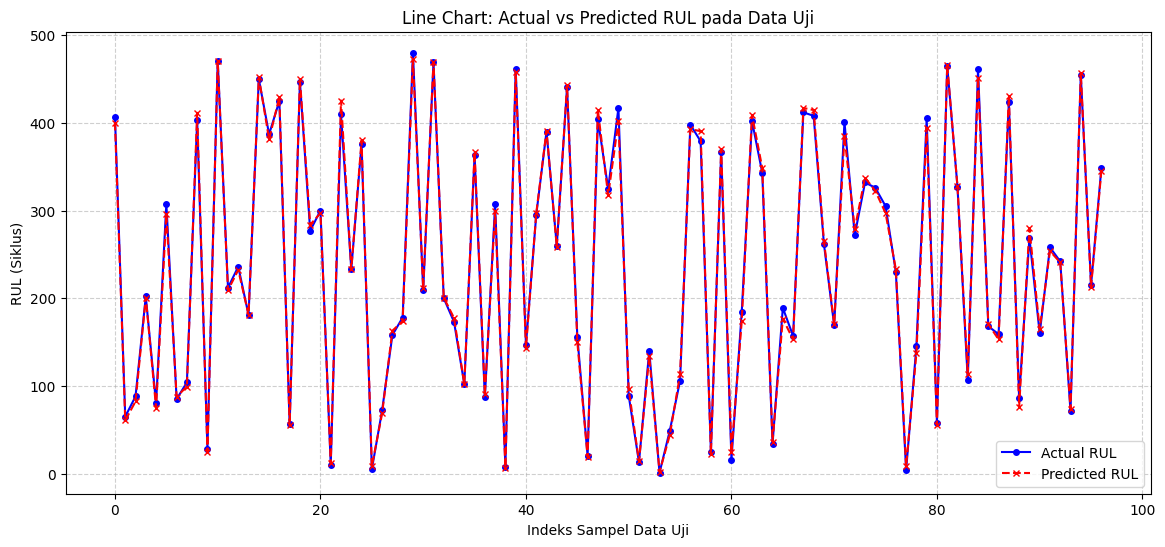

In [35]:
plt.figure(figsize=(14, 6))
plt.plot(np.array(y_test), label='Actual RUL', marker='o', linestyle='-', color='blue', markersize=4)
plt.plot(y_pred, label='Predicted RUL', marker='x', linestyle='--', color='red', markersize=4)
plt.title('Line Chart: Actual vs Predicted RUL pada Data Uji')
plt.xlabel('Indeks Sampel Data Uji')
plt.ylabel('RUL (Siklus)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 8. Feature Importance (Tingkat Kepentingan Fitur)

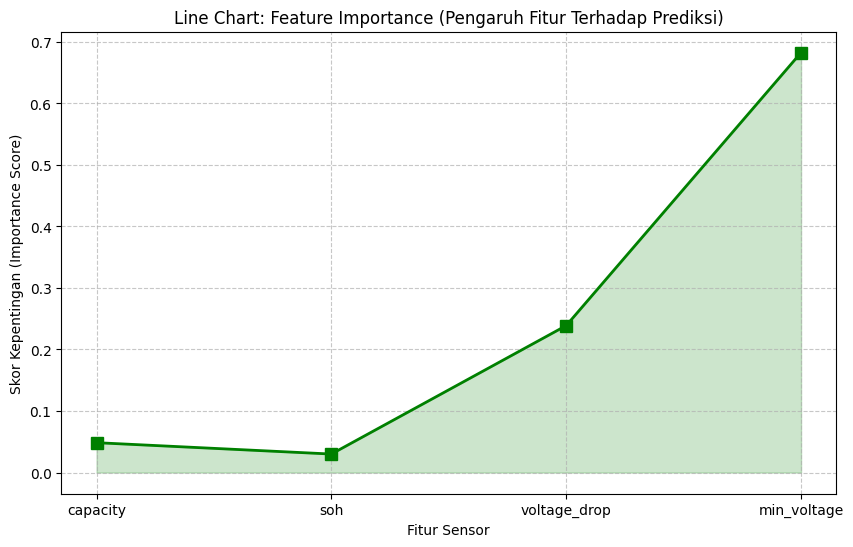

In [36]:
importance = model.feature_importances_
plt.figure(figsize=(10, 6))
# Membuat Line Chart sesuai request
plt.plot(features, importance, marker='s', linestyle='-', color='green', linewidth=2, markersize=8)
plt.fill_between(features, importance, alpha=0.2, color='green') # Menambahkan efek fill di bawah garis
plt.title('Line Chart: Feature Importance (Pengaruh Fitur Terhadap Prediksi)')
plt.xlabel('Fitur Sensor')
plt.ylabel('Skor Kepentingan (Importance Score)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()